# Ejercicio

Carlos Emiliano Mendoza Hernandez

## Predecir el resultado de una eleccion con base en encuesta de salida

Para elecciones grandes, agencias de medios utilizan encuestas de salida de votantes para ayudar a predecir el/la ganador/a antes de que se cuenten los votos. Para la eleccion presidencial de 2020 de Estados Unidos, en un cuestionario de salida de votantes de California se obtuvo que el $65.5\%$ contesto haber votado por Biden. La  muestra fue de solo 2271 votantes de una poblacion adulta de 17M. Con esto se predijo que Biden ganaria California y obtendria sus votos del colegio electoral. ¿Como esta encuesta de salida del $0.01\%$ podria tener suficiente informacion para predecir el ganador? A traves de simulacion, ¿como se podria decidir si Biden gano el estado de California con base en esta muestra?

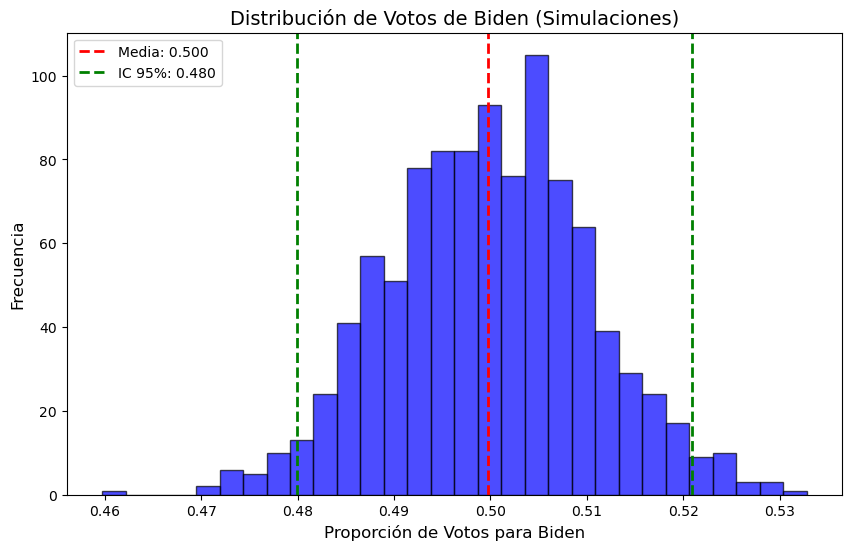

Intervalo de confianza del 95%: [0.47995376 0.5209159 ]
Proporción muestral observada (p̂): 0.4998
Estadístico Z: -0.0200
Valor p: 0.5080
No se rechaza la hipótesis nula: no hay suficiente evidencia para decir que p > 0.5.


In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Parámetros de la simulación
p_0 = 0.5  # Hipótesis nula: proporción de votos esperada
n_votantes = 2271  # Tamaño de la muestra
n_simulaciones = 1000  # Número de simulaciones

# Simular encuestas con probabilidad de 0.5 (escenario neutral)
simulaciones = np.random.binomial(n_votantes, 0.5, n_simulaciones) / n_votantes

# Calcular el intervalo de confianza del 95%
intervalo_confianza = np.percentile(simulaciones, [2.5, 97.5])

# Media de las simulaciones (proporción muestral)
p_hat = np.mean(simulaciones)

# Estadístico Z y p-valor
z_stat = (p_hat - p_0) / np.sqrt((p_0 * (1 - p_0)) / n_votantes)
p_value = 1 - stats.norm.cdf(z_stat)  # Prueba de una cola (p > 0.5)

# Graficar la distribución de simulaciones
plt.figure(figsize=(10, 6))
plt.hist(simulaciones, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(p_hat, color='red', linestyle='dashed', linewidth=2, label=f'Media: {p_hat:.3f}')
plt.axvline(intervalo_confianza[0], color='green', linestyle='dashed', linewidth=2, label=f'IC 95%: {intervalo_confianza[0]:.3f}')
plt.axvline(intervalo_confianza[1], color='green', linestyle='dashed', linewidth=2)

plt.title('Distribución de Votos de Biden (Simulaciones)', fontsize=14)
plt.xlabel('Proporción de Votos para Biden', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.show()

print(f"Intervalo de confianza del 95%: {intervalo_confianza}")
print(f"Proporción muestral observada (p̂): {p_hat:.4f}")
print(f"Estadístico Z: {z_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Conclusión de la prueba
alpha = 0.05  # Nivel de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de que p > 0.5.")
else:
    print("No se rechaza la hipótesis nula: no hay suficiente evidencia para decir que p > 0.5.")


1. **Intervalo de confianza (IC 95%):**  
   $$
   [0.4799, 0.5209]
   $$
   - Esto significa que, con un **95% de confianza**, la proporción real de votos para Biden en la población se encuentra entre **47.99% y 52.09%**.

2. **Proporción muestral observada ($ p̂ $):**  
   $$
   0.4998
   $$
   - La proporción promedio obtenida en las simulaciones es **49.98%**, lo que está muy cerca de **50%**, la hipótesis nula.

3. **Estadístico $ Z $:**  
   $$
   -0.0200
   $$
   - Un valor cercano a **0** indica que la proporción observada no es significativamente mayor a **50%**.

4. **Valor $ p $:**  
   $$
   0.5080
   $$
   - Este es el **p-valor** para una prueba de una sola cola (\( H_A: p > 0.5 \)).
   - Como **\( p = 0.508 \) es mucho mayor que \( \alpha = 0.05 \)**, **no podemos rechazar la hipótesis nula**.

**No hay suficiente evidencia estadística para afirmar que la proporción de votos para Biden es mayor al 50%.**  
Dicho de otra forma, los resultados sugieren que la proporción de votos para Biden podría ser **igual o menor** al 50%, pero no podemos asegurarlo con un 95% de confianza.